In [18]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict
from IPython.display import display, Image
from typing import Annotated
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

In [19]:
class BoatState(TypedDict):
    messages : Annotated[list, add_messages]

In [20]:
load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

llm = ChatGroq(model ='qwen/qwen3-32b')
llm.invoke('Hello, I am Kunal and I like to play games')

AIMessage(content="<think>\nOkay, the user is Kunal and he mentioned he likes to play games. I should respond in a friendly and engaging way. Let's see, I need to acknowledge his introduction and show interest in his hobby. Maybe ask him about his favorite games or what kind of games he enjoys. That way, we can have a conversation and he might share more. I should keep it open-ended so he can talk about what he wants. Also, maybe mention different genres like video games, board games, or outdoor games. Let him know I'm here to chat about games. Keep the tone positive and welcoming. Alright, time to put that into a response.\n</think>\n\nHello Kunal! Nice to meet you! 🎮 Sounds like you have a great hobby—games can be so much fun! Do you have a favorite type of game? Video games, board games, or maybe something else? I'd love to hear what you're into!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 194, 'prompt_tokens': 20, 'total_tokens': 214, 'completion

In [21]:
def myboat(state: BoatState):
    return {"messages": [llm.invoke(state['messages'])]}

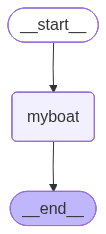

In [22]:
graph = StateGraph(BoatState)

graph.add_node("myboat",myboat)

graph.add_edge(START,"myboat")
graph.add_edge("myboat", END)

graph_bulder = graph.compile()

display(Image(graph_bulder.get_graph().draw_mermaid_png()))

In [24]:
graph_bulder.invoke({'messages':"Hello Boat, Can you help me in LLM? I need Study Path of LLM"})

{'messages': [HumanMessage(content='Hello Boat, Can you help me in LLM? I need Study Path of LLM', additional_kwargs={}, response_metadata={}, id='91547d61-0f5d-42dd-b2dc-71a2362fa354'),
  AIMessage(content='<think>\nOkay, the user is asking for a study path to learn about Large Language Models (LLMs). Let me break down what they might need. First, they probably want a structured approach, so I should outline the steps from basics to advanced topics. Starting with foundational knowledge is essential—math, basic programming, and machine learning concepts. Then moving into NLP since LLMs are heavily used there. \n\nI need to make sure each step builds on the previous one. Maybe start with math prerequisites like linear algebra, probability, and calculus. Then programming in Python, which is the primary language for ML. After that, an introduction to ML concepts like supervised learning, neural networks, and datasets. \n\nNext, dive into NLP basics: text preprocessing, tokenization, word 

In [25]:
graph_bulder.stream({'messages': "I am Kunal, How are are you?"})

<generator object Pregel.stream at 0x000001218FCDBE00>

In [28]:
for event in graph_bulder.stream({'messages': "I am Kunal, How are are you?"}, stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='I am Kunal, How are are you?', additional_kwargs={}, response_metadata={}, id='b2932eb6-c407-4b40-9145-cd9bb4ff5eed')]}
{'messages': [HumanMessage(content='I am Kunal, How are are you?', additional_kwargs={}, response_metadata={}, id='b2932eb6-c407-4b40-9145-cd9bb4ff5eed'), AIMessage(content="<think>\nOkay, the user introduced himself as Kunal and asked how I am. I should respond with a friendly greeting and let him know I'm here to help. Keep it simple and positive.\n\nFirst, acknowledge his name to make it personal. Then, offer assistance with anything he needs. Keep the tone friendly and open-ended. Maybe add an emoji to keep it light and approachable. Let him know I'm an AI and ready to help with questions or tasks. Make sure the response is concise and not too wordy. Check for any typos or errors before sending.\n</think>\n\nHello Kunal! I'm doing well, thank you! 😊 How can I assist you today? Feel free to ask me any questions or let me know if 